# 🇨🇴 Altitud de Municipios Colombianos

Obtiene la altitud (msnm) de todos los municipios usando:
- **DIVIPOLA** (datos.gov.co) — listado oficial con coordenadas
- **Open-Elevation API** — servicio gratuito basado en SRTM NASA

**Resultado:** `municipios_colombia_altitud.csv` con código DIVIPOLA, nombre, departamento, coordenadas y altitud.

## Paso 1 — Instalar dependencias

In [1]:
!pip install requests pandas tqdm --quiet

## Paso 2 — Descargar DIVIPOLA y detectar columnas automáticamente

In [2]:
import pandas as pd
import requests
import time
from tqdm import tqdm

# URL del dataset DIVIPOLA geolocalizados
URL = 'https://www.datos.gov.co/api/views/vafm-j2df/rows.csv?accessType=DOWNLOAD'

print('Descargando DIVIPOLA...')
df_raw = pd.read_csv(URL, low_memory=False)
print(f'✅ {len(df_raw)} filas descargadas')
print(f'\nColumnas disponibles ({len(df_raw.columns)}):')
print(df_raw.columns.tolist())
print()
print('Primeras filas:')
df_raw.head(3)

Descargando DIVIPOLA...
✅ 1121 filas descargadas

Columnas disponibles (8):
['COD_DPTO', 'NOM_DPTO', 'COD_MPIO', 'NOM_MPIO', 'TIPO', 'LATITUD', 'LONGITUD', 'Geo Municipio']

Primeras filas:


,COD_DPTO,NOM_DPTO,COD_MPIO,NOM_MPIO,TIPO,LATITUD,LONGITUD,Geo Municipio
0,5,ANTIOQUIA,5001,MEDELLÍN,Municipio,6.257590,-75.611031,POINT (-75.61103107 6.257590259)
1,5,ANTIOQUIA,5002,ABEJORRAL,Municipio,5.803728,-75.438474,POINT (-75.43847353 5.803728154)
2,5,ANTIOQUIA,5004,ABRIAQUÍ,Municipio,6.627569,-76.085978,POINT (-76.08597756 6.627569378)


## Paso 3 — Mapear columnas al nombre estándar

In [3]:
# El dataset DIVIPOLA puede tener distintos nombres de columna.
# Esta celda los detecta automáticamente buscando palabras clave.

def encontrar_columna(df, palabras_clave):
    """Devuelve el nombre de la primera columna que contenga alguna palabra clave."""
    for col in df.columns:
        col_norm = col.lower().replace(' ', '').replace('_', '')
        for palabra in palabras_clave:
            if palabra.lower() in col_norm:
                return col
    return None

col_codigo = encontrar_columna(df_raw, ['codigomunicipio', 'codmunicipio', 'codigodane', 'codigodivipola', 'dpto_ccdgo'])
col_mun    = encontrar_columna(df_raw, ['nombremunicipio', 'municipio', 'nommunicipio'])
col_dpto   = encontrar_columna(df_raw, ['nombredepartamento', 'departamento', 'nomdepartamento'])
col_lat    = encontrar_columna(df_raw, ['latitud', 'lat', 'latitude', 'geo_point_2d'])
col_lon    = encontrar_columna(df_raw, ['longitud', 'lon', 'longitude', 'lng'])

print('Columnas detectadas:')
print(f'  Código DIVIPOLA : {col_codigo}')
print(f'  Municipio       : {col_mun}')
print(f'  Departamento    : {col_dpto}')
print(f'  Latitud         : {col_lat}')
print(f'  Longitud        : {col_lon}')

# Si hay columna geo_point_2d (formato 'lat,lon'), separarla
if col_lat and 'geo_point' in col_lat.lower():
    print('\nDetectada columna geo_point_2d, separando lat/lon...')
    coords = df_raw[col_lat].str.split(',', expand=True)
    df_raw['_latitud']  = pd.to_numeric(coords[0], errors='coerce')
    df_raw['_longitud'] = pd.to_numeric(coords[1], errors='coerce')
    col_lat = '_latitud'
    col_lon = '_longitud'
    print(f'  → lat: {col_lat}, lon: {col_lon}')

Columnas detectadas:
  Código DIVIPOLA : None
  Municipio       : Geo Municipio
  Departamento    : None
  Latitud         : LATITUD
  Longitud        : LONGITUD


In [4]:
# Construir dataframe estandarizado
cols_disponibles = {}
if col_codigo: cols_disponibles[col_codigo] = 'codigo_divipola'
if col_mun:    cols_disponibles[col_mun]    = 'municipio'
if col_dpto:   cols_disponibles[col_dpto]   = 'departamento'
if col_lat:    cols_disponibles[col_lat]    = 'latitud'
if col_lon:    cols_disponibles[col_lon]    = 'longitud'

df = df_raw[list(cols_disponibles.keys())].rename(columns=cols_disponibles).copy()

# Convertir a numérico y eliminar sin coordenadas
df['latitud']  = pd.to_numeric(df['latitud'],  errors='coerce')
df['longitud'] = pd.to_numeric(df['longitud'], errors='coerce')
df = df.dropna(subset=['latitud', 'longitud'])

# Código DIVIPOLA a 5 dígitos
if 'codigo_divipola' in df.columns:
    df['codigo_divipola'] = (
        pd.to_numeric(df['codigo_divipola'], errors='coerce')
        .astype('Int64').astype(str)
        .str.replace('<NA>', '')
        .str.zfill(5)
    )

print(f'Municipios con coordenadas válidas: {len(df)}')
df.head()

Municipios con coordenadas válidas: 1121


,municipio,latitud,longitud
0,POINT (-75.61103107 6.257590259),6.257590,-75.611031
1,POINT (-75.43847353 5.803728154),5.803728,-75.438474
2,POINT (-76.08597756 6.627569378),6.627569,-76.085978
3,POINT (-75.09059702 6.365534125),6.365534,-75.090597
4,POINT (-75.7080031 6.032921994),6.032922,-75.708003


## Paso 4 — Consultar altitud via Open-Elevation API

Consulta en lotes de 100 puntos. Tarda ~5-10 minutos para todos los municipios.

In [5]:
def obtener_altitudes(df_mun, batch_size=100, pausa=1.0):
    API_URL = 'https://api.open-elevation.com/api/v1/lookup'
    altitudes = []
    filas = df_mun[['latitud', 'longitud']].values.tolist()

    for i in tqdm(range(0, len(filas), batch_size), desc='Consultando altitudes'):
        lote = filas[i:i + batch_size]
        payload = {'locations': [{'latitude': lat, 'longitude': lon} for lat, lon in lote]}

        for intento in range(3):
            try:
                resp = requests.post(API_URL, json=payload, timeout=30)
                resp.raise_for_status()
                altitudes.extend([r['elevation'] for r in resp.json()['results']])
                break
            except Exception as e:
                if intento < 2:
                    print(f'  ⚠️ Reintentando lote {i//batch_size + 1}... ({e})')
                    time.sleep(3)
                else:
                    print(f'  ❌ Fallo lote {i//batch_size + 1}: {e}')
                    altitudes.extend([None] * len(lote))
        time.sleep(pausa)

    return altitudes

print(f'Consultando altitudes para {len(df)} municipios...')
print('Esto puede tardar 5-10 minutos ⏳')
df['altitud_msnm'] = obtener_altitudes(df)
print('✅ Altitudes obtenidas')

Consultando altitudes para 1121 municipios...
Esto puede tardar 5-10 minutos ⏳


Consultando altitudes: 100%|██████████| 12/12 [00:32<00:00,  2.70s/it]

✅ Altitudes obtenidas


## Paso 5 — Agregar categoría altitudinal (para modelo dengue)

In [6]:
def cat_altitud(m):
    if pd.isna(m):  return 'Sin dato'
    if m < 1000:    return 'Bajo (<1.000 m)'
    if m < 1800:    return 'Medio (1.000-1.800 m)'
    if m < 2200:    return 'Alto (1.800-2.200 m)'
    return 'Muy alto (>2.200 m)'

df['cat_altitud'] = df['altitud_msnm'].apply(cat_altitud)

print('Estadísticas:')
print(df['altitud_msnm'].describe().round(1))
print()
print('Distribución por categoría:')
print(df['cat_altitud'].value_counts())
print()
print('Top 5 municipios más altos:')
cols_show = [c for c in ['municipio','departamento','altitud_msnm'] if c in df.columns]
print(df.nlargest(5, 'altitud_msnm')[cols_show].to_string())

Estadísticas:
count    1121.0
mean     1259.6
std      1010.9
min         0.0
25%       217.0
50%      1226.0
75%      2055.0
max      3919.0
Name: altitud_msnm, dtype: float64

Distribución por categoría:
cat_altitud
Bajo (<1.000 m)          494
Medio (1.000-1.800 m)    271
Muy alto (>2.200 m)      247
Alto (1.800-2.200 m)     109
Name: count, dtype: int64

Top 5 municipios más altos:
                            municipio  altitud_msnm
237  POINT (-72.25599334 6.566991765)        3919.0
232  POINT (-72.72964765 5.799050256)        3891.0
300  POINT (-72.72626817 5.882294313)        3712.0
212   POINT (-72.41795675 6.68911806)        3619.0
292   POINT (-72.8709565 5.646672053)        3606.0


## Paso 6 — Exportar CSV y descargar

In [7]:
SALIDA = 'municipios_colombia_altitud.csv'
df.to_csv(SALIDA, index=False, encoding='utf-8-sig')
print(f'✅ Guardado: {SALIDA}')
print(f'   Filas: {len(df)} | Columnas: {list(df.columns)}')

from google.colab import files
files.download(SALIDA)

✅ Guardado: municipios_colombia_altitud.csv
   Filas: 1121 | Columnas: ['municipio', 'latitud', 'longitud', 'altitud_msnm', 'cat_altitud']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Paso 7 (Opcional) — Mapa y distribución

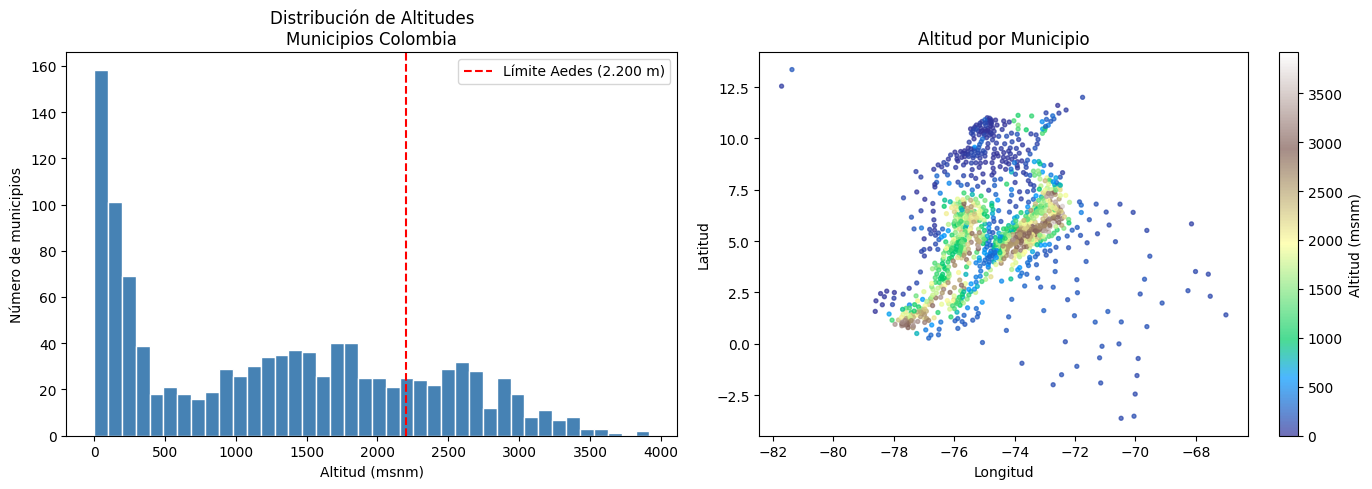

✅ Mapa guardado


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['altitud_msnm'].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Altitudes\nMunicipios Colombia')
axes[0].set_xlabel('Altitud (msnm)')
axes[0].set_ylabel('Número de municipios')
axes[0].axvline(2200, color='red', linestyle='--', label='Límite Aedes (2.200 m)')
axes[0].legend()

sc = axes[1].scatter(
    df['longitud'], df['latitud'],
    c=df['altitud_msnm'], cmap='terrain', s=8, alpha=0.7
)
plt.colorbar(sc, ax=axes[1], label='Altitud (msnm)')
axes[1].set_title('Altitud por Municipio')
axes[1].set_xlabel('Longitud')
axes[1].set_ylabel('Latitud')

plt.tight_layout()
plt.savefig('mapa_altitud_colombia.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Mapa guardado')